# **LITERACY_RATES**

In [1]:
import pandas as pd
df_adult = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_adult.head()

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


In [2]:
df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_youth.head()

,entity,code,year,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,71.00000,42.00000,Asia
4,Afghanistan,AFG,2022,83.40000,44.17171,Asia


In [3]:
#Combine the data into df_literacy → Adult & Youth Literacy Rates
df_literacy = pd.merge(df_adult,df_youth,on=('entity', 'code', 'year'))
df_literacy

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1703,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1704,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1705,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
1706,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


In [4]:
#Renaming the columns for better understanding
df_literacy = df_literacy.rename(columns={
    "entity": 'country',
    "code": 'country_code',
    "adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99": 'adult_literacy_both_sexes_age15to99',
    "youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m": 'youth_literacy_male_age15to24',
    "youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f": 'youth_literacy_female_age15to24',
    "owid_region": "continent"
})
df_literacy.head()

,country,country_code,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24,continent
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe


In [5]:
df_literacy.describe()

,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24
count,1708.000000,1708.000000,1708.000000,1708.000000
mean,2003.856557,77.337579,89.016848,83.591187
std,13.192679,19.312535,12.667570,19.246105
min,1970.000000,9.000000,22.000000,7.000000
25%,1994.000000,64.441170,82.819005,72.948222
50%,2007.000000,82.143840,94.000000,92.000000
75%,2015.000000,94.000000,98.479942,98.835233
max,2023.000000,100.000000,100.000000,100.000000


In [6]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708 entries, 0 to 1707
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              1708 non-null   object 
 1   country_code                         979 non-null    object 
 2   year                                 1708 non-null   int64  
 3   adult_literacy_both_sexes_age15to99  1708 non-null   float64
 4   youth_literacy_male_age15to24        1708 non-null   float64
 5   youth_literacy_female_age15to24      1708 non-null   float64
 6   continent                            931 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 93.5+ KB


In [7]:
x = df_literacy[df_literacy['country_code'].isnull()]['country'].unique()
x1 = pd.DataFrame(x, columns=['country'])
x1

,country
0,Central and Southern Asia (SDG)
1,East Asia and Pacific (WB)
2,Eastern and South-Eastern Asia (SDG)
3,Europe and Central Asia (WB)
4,Europe and Northern America (SDG)
5,Latin America and Caribbean (WB)
6,Latin America and the Caribbean (SDG)
7,Low-income countries
8,Lower-middle-income countries
9,Middle East and North Africa (WB)


In [8]:
y =  df_literacy[df_literacy['continent'].isnull()]['country'].unique()
y1 = pd.DataFrame(y, columns=['country'])
y1

,country
0,Central and Southern Asia (SDG)
1,East Asia and Pacific (WB)
2,Eastern and South-Eastern Asia (SDG)
3,Europe and Central Asia (WB)
4,Europe and Northern America (SDG)
5,Latin America and Caribbean (WB)
6,Latin America and the Caribbean (SDG)
7,Low-income countries
8,Lower-middle-income countries
9,Middle East and North Africa (WB)


In [9]:
#Get the list of regions where continent is null
target_regions = df_literacy[df_literacy['continent'].isnull()]['country'].unique()

#Identify the rows and update the specific columns
mask = df_literacy['country'].isin(target_regions)

df_literacy.loc[mask, 'country'] = 'Others'
df_literacy.loc[mask, 'country_code'] = 'Others'
df_literacy.loc[mask, 'continent'] = 'Others'

# Now all those specific regions are labeled "Others"
df_literacy

,country,country_code,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24,continent
0,Afghanistan,AFG,1979,18.00000,46.00000,11.00000,Asia
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1703,Zambia,ZMB,2010,83.00000,91.00000,87.00000,Africa
1704,Zambia,ZMB,2018,71.13230,82.44786,72.90992,Africa
1705,Zimbabwe,ZWE,1982,78.00000,94.00000,85.00000,Africa
1706,Zimbabwe,ZWE,1992,84.00000,97.00000,94.00000,Africa


In [10]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708 entries, 0 to 1707
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              1708 non-null   object 
 1   country_code                         1708 non-null   object 
 2   year                                 1708 non-null   int64  
 3   adult_literacy_both_sexes_age15to99  1708 non-null   float64
 4   youth_literacy_male_age15to24        1708 non-null   float64
 5   youth_literacy_female_age15to24      1708 non-null   float64
 6   continent                            1708 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 93.5+ KB


In [11]:
df_literacy.describe()

,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24
count,1708.000000,1708.000000,1708.000000,1708.000000
mean,2003.856557,77.337579,89.016848,83.591187
std,13.192679,19.312535,12.667570,19.246105
min,1970.000000,9.000000,22.000000,7.000000
25%,1994.000000,64.441170,82.819005,72.948222
50%,2007.000000,82.143840,94.000000,92.000000
75%,2015.000000,94.000000,98.479942,98.835233
max,2023.000000,100.000000,100.000000,100.000000


In [12]:
#Finding the Duplicates
df_literacy.duplicated().sum()

np.int64(0)

In [13]:
# Find the index of all rows where year is 1990 or less, then drop them
df_literacy = df_literacy.drop(df_literacy[df_literacy['year'] < 1990].index)
df_literacy.describe()

,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24
count,1405.000000,1405.000000,1405.000000,1405.000000
mean,2008.554448,80.042404,90.387280,86.272507
std,9.109381,18.086364,11.916495,17.411604
min,1990.000000,11.000000,25.000000,9.000000
25%,2001.000000,67.267330,86.000000,76.613550
50%,2010.000000,86.747480,96.000000,95.528910
75%,2016.000000,94.771680,98.783860,99.000000
max,2023.000000,100.000000,100.000000,100.000000


In [14]:
#----------------------------------------------------------
#  Creating new columns for deeper insights of the Data
#----------------------------------------------------------

#Gender Gap in the younger generation
df_literacy['youth_gender_gap'] = df_literacy['youth_literacy_male_age15to24'] - df_literacy['youth_literacy_female_age15to24']

#Difference between Youth and Adult (The "Lift")
df_literacy['total_youth_avg'] = (df_literacy['youth_literacy_male_age15to24'] + df_literacy['youth_literacy_female_age15to24']) / 2
df_literacy['generational_lift'] = df_literacy['total_youth_avg'] - df_literacy['adult_literacy_both_sexes_age15to99']

#Simple combined Youth metric
df_literacy['total_youth_literacy'] = df_literacy['total_youth_avg']

#Calculate the average Youth Literacy
df_literacy['youth_avg'] = (df_literacy['youth_literacy_male_age15to24'] + df_literacy['youth_literacy_female_age15to24']) / 2

#Calculate the Generational Lift (Youth minus Adult)
df_literacy['generational_lift'] = df_literacy['youth_avg'] - df_literacy['adult_literacy_both_sexes_age15to99']

#Aggregate by continent to find the highest average lift
continent_lift = df_literacy.groupby('continent')['generational_lift'].mean().sort_values(ascending=False)

print("Generational Lift by Continent:")
print(continent_lift)


Generational Lift by Continent:
continent
Africa           13.022216
Others            8.910652
North America     7.758158
Asia              6.971509
South America     4.909478
Oceania           2.621973
Europe            2.098648
Name: generational_lift, dtype: float64


In [15]:
df_literacy.head()

,country,country_code,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24,continent,youth_gender_gap,total_youth_avg,generational_lift,total_youth_literacy,youth_avg
1,Afghanistan,AFG,2011,31.00000,62.00000,32.00000,Asia,30.00000,47.000000,16.000000,47.000000,47.000000
2,Afghanistan,AFG,2015,33.75384,57.73505,25.48416,Asia,32.25089,41.609605,7.855765,41.609605,41.609605
3,Afghanistan,AFG,2021,37.00000,71.00000,42.00000,Asia,29.00000,56.500000,19.500000,56.500000,56.500000
4,Albania,ALB,2001,99.00000,99.00000,99.00000,Europe,0.00000,99.000000,0.000000,99.000000,99.000000
5,Albania,ALB,2008,96.00000,99.00000,99.00000,Europe,0.00000,99.000000,3.000000,99.000000,99.000000


In [16]:
df_literacy.describe()

,year,adult_literacy_both_sexes_age15to99,youth_literacy_male_age15to24,youth_literacy_female_age15to24,youth_gender_gap,total_youth_avg,generational_lift,total_youth_literacy,youth_avg
count,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000,1405.000000
mean,2008.554448,80.042404,90.387280,86.272507,4.114773,88.329894,8.287490,88.329894,88.329894
std,9.109381,18.086364,11.916495,17.411604,6.801157,14.526509,5.723476,14.526509,14.526509
min,1990.000000,11.000000,25.000000,9.000000,-19.000000,17.500000,-5.500000,17.500000,17.500000
25%,2001.000000,67.267330,86.000000,76.613550,0.000000,81.000000,3.950000,81.000000,81.000000
50%,2010.000000,86.747480,96.000000,95.528910,0.424560,95.442225,7.352620,95.442225,95.442225
75%,2016.000000,94.771680,98.783860,99.000000,7.778180,98.870335,12.050000,98.870335,98.870335
max,2023.000000,100.000000,100.000000,100.000000,48.000000,100.000000,31.000000,100.000000,100.000000


In [17]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1405 entries, 1 to 1707
Data columns (total 12 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   country                              1405 non-null   object 
 1   country_code                         1405 non-null   object 
 2   year                                 1405 non-null   int64  
 3   adult_literacy_both_sexes_age15to99  1405 non-null   float64
 4   youth_literacy_male_age15to24        1405 non-null   float64
 5   youth_literacy_female_age15to24      1405 non-null   float64
 6   continent                            1405 non-null   object 
 7   youth_gender_gap                     1405 non-null   float64
 8   total_youth_avg                      1405 non-null   float64
 9   generational_lift                    1405 non-null   float64
 10  total_youth_literacy                 1405 non-null   float64
 11  youth_avg                          

In [18]:
lit = df_literacy
lit.to_excel("Lit.xlsx")

# **Illiteracy_Population**

In [19]:
df_illiterate = pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiterate.head()

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [20]:
#Renaming the columns for better understanding
df_illiterate = df_illiterate.rename(columns=
   {"entity" : "country",
    "code": 'country_code'})
df_illiterate.head()

,country,country_code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000


In [21]:
df_illiterate.describe()

,year,illiteracy_rate,literacy_rate
count,2059.000000,2059.000000,2059.000000
mean,1986.084507,27.421922,72.578078
std,64.008447,24.485748,24.485748
min,1475.000000,0.000000,0.000000
25%,1983.000000,6.704529,57.981690
50%,2002.000000,21.000000,79.000000
75%,2013.000000,42.018310,93.295470
max,2023.000000,100.000000,100.000000


In [22]:
df_illiterate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2059 non-null   object 
 1   country_code     1326 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy_rate  2059 non-null   float64
 4   literacy_rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.6+ KB


In [23]:
z = df_illiterate[df_illiterate['country_code'].isnull()]['country'].unique()
z1 = pd.DataFrame(y, columns=['country'])
z1

,country
0,Central and Southern Asia (SDG)
1,East Asia and Pacific (WB)
2,Eastern and South-Eastern Asia (SDG)
3,Europe and Central Asia (WB)
4,Europe and Northern America (SDG)
5,Latin America and Caribbean (WB)
6,Latin America and the Caribbean (SDG)
7,Low-income countries
8,Lower-middle-income countries
9,Middle East and North Africa (WB)


In [24]:
#Get the list of regions where continent is null
target_regions =df_illiterate[df_illiterate['country_code'].isnull()]['country'].unique()

#Identify the rows and update the specific columns
mask = df_illiterate['country'].isin(target_regions)

df_illiterate.loc[mask, 'country'] = 'Others'
df_illiterate.loc[mask, 'country_code'] = 'Others'

#Now all those specific regions are labeled "Others"
df_illiterate

,country,country_code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [25]:
df_illiterate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2059 non-null   object 
 1   country_code     2059 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy_rate  2059 non-null   float64
 4   literacy_rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 80.6+ KB


In [26]:
df_illiterate.describe()

,year,illiteracy_rate,literacy_rate
count,2059.000000,2059.000000,2059.000000
mean,1986.084507,27.421922,72.578078
std,64.008447,24.485748,24.485748
min,1475.000000,0.000000,0.000000
25%,1983.000000,6.704529,57.981690
50%,2002.000000,21.000000,79.000000
75%,2013.000000,42.018310,93.295470
max,2023.000000,100.000000,100.000000


In [27]:
#Finding the Duplicate
df_illiterate.duplicated().sum()

np.int64(3)

In [28]:
# Shows only the rows that are duplicates but they are not duplicated, so need need to drop the rows
df_illiterate[df_illiterate.duplicated()]

,country,country_code,year,illiteracy_rate,literacy_rate
878,Others,Others,2020,5.686691,94.31331
879,Others,Others,2021,5.506180,94.49382
880,Others,Others,2022,5.353081,94.64692


In [29]:
# Find the index of all rows where year is 1990 or less, then drop them
df_illiterate = df_illiterate.drop(df_illiterate[df_illiterate['year'] < 1990].index)
df_illiterate.describe()

,year,illiteracy_rate,literacy_rate
count,1419.000000,1419.000000,1419.000000
mean,2008.534179,20.013274,79.986726
std,9.101880,18.144772,18.144772
min,1990.000000,0.000000,11.000000
25%,2001.000000,5.263798,67.227155
50%,2010.000000,13.348106,86.651890
75%,2016.000000,32.772847,94.736200
max,2023.000000,89.000000,100.000000


In [30]:
#----------------------------------------------------------
#  Creating new columns for deeper insights of the Data
#----------------------------------------------------------

#Ensure chronological order for the progress calculation
df_illiterate = df_illiterate.sort_values(['country', 'year'])

#Strength Ratio
# Note: replace 0 with a tiny number to avoid division by zero
df_illiterate['lit_to_illit_ratio'] = df_illiterate['literacy_rate'] / df_illiterate['illiteracy_rate'].replace(0, 0.01)

#Annual Progress (Year-over-Year change)
df_illiterate['annual_progress'] = df_illiterate.groupby('country')['literacy_rate'].diff().fillna(0)

#Data Integrity Check
df_illiterate['data_gap'] = 100 - (df_illiterate['literacy_rate'] + df_illiterate['illiteracy_rate'])
df_illiterate.head()

,country,country_code,year,illiteracy_rate,literacy_rate,lit_to_illit_ratio,annual_progress,data_gap
2,Afghanistan,AFG,2011,69.000000,31.00000,0.449275,0.00000,0.000000
3,Afghanistan,AFG,2015,66.246155,33.75384,0.509521,2.75384,0.000005
4,Afghanistan,AFG,2021,63.000000,37.00000,0.587302,3.24616,0.000000
6,Albania,ALB,2001,1.000000,99.00000,99.000000,0.00000,0.000000
7,Albania,ALB,2008,4.000000,96.00000,24.000000,-3.00000,0.000000


In [31]:
df_illiterate.describe()

,year,illiteracy_rate,literacy_rate,lit_to_illit_ratio,annual_progress,data_gap
count,1419.000000,1419.000000,1419.000000,1419.000000,1419.000000,1.419000e+03
mean,2008.534179,20.013274,79.986726,345.479416,0.948825,3.320648e-08
std,9.101880,18.144772,18.144772,1787.736539,10.820466,1.342328e-06
min,1990.000000,0.000000,11.000000,0.123596,-38.736640,-4.000000e-06
25%,2001.000000,5.263798,67.227155,2.051311,0.000000,0.000000e+00
50%,2010.000000,13.348106,86.651890,6.491699,0.000070,0.000000e+00
75%,2016.000000,32.772847,94.736200,17.998117,3.445600,0.000000e+00
max,2023.000000,89.000000,100.000000,10000.000000,35.214170,5.000000e-06


In [32]:
df_illiterate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1419 entries, 2 to 2058
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             1419 non-null   object 
 1   country_code        1419 non-null   object 
 2   year                1419 non-null   int64  
 3   illiteracy_rate     1419 non-null   float64
 4   literacy_rate       1419 non-null   float64
 5   lit_to_illit_ratio  1419 non-null   float64
 6   annual_progress     1419 non-null   float64
 7   data_gap            1419 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 99.8+ KB


In [33]:
illit = df_illiterate
illit.to_excel("Illit.xlsx")

# **Gdp_Schooling**

In [34]:
df_gdp = pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_gdp.head()

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [35]:
df_Avgschooling = pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_Avgschooling.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [36]:
##Combine the data into df_gdp_schooling → GDP & Years of Schooling
df_gdp_schooling = pd.merge(df_gdp,df_Avgschooling,on=('entity', 'code', 'year','owid_region'))
df_gdp_schooling

,entity,code,year,ny_gdp_pcap_pp_kd,owid_region,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical
0,Afghanistan,AFG,2000,1617.8264,Asia,NaN,3.03,20130334.0
1,Afghanistan,AFG,2005,1908.1147,Asia,NaN,3.32,24404575.0
2,Afghanistan,AFG,2010,2848.5862,Asia,NaN,3.93,28284088.0
3,Afghanistan,AFG,2011,2757.0525,Asia,31.00000,NaN,29347708.0
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0
...,...,...,...,...,...,...,...,...
1487,Zimbabwe,ZWE,2005,4004.6646,Africa,NaN,7.65,12483433.0
1488,Zimbabwe,ZWE,2010,3885.3938,Africa,NaN,7.86,13356551.0
1489,Zimbabwe,ZWE,2015,5102.7144,Africa,NaN,8.03,14399008.0
1490,Zimbabwe,ZWE,2019,4993.8438,Africa,93.22755,NaN,15271377.0


In [37]:
#Renaming the columns for better understanding
df_gdp_schooling = df_gdp_schooling.rename(columns={
    "entity": 'country',
    "code": 'country_code',
    "ny_gdp_pcap_pp_kd": 'gdp',
    "mf_youth_and_adults__15_64_years__average_years_of_education": 'average_schooling_year_both_sexes_age15to64',
    "owid_region": "continent"
})
df_gdp_schooling.head()

,country,country_code,year,gdp,continent,literacy_rate,average_schooling_year_both_sexes_age15to64,population_historical
0,Afghanistan,AFG,2000,1617.8264,Asia,NaN,3.03,20130334.0
1,Afghanistan,AFG,2005,1908.1147,Asia,NaN,3.32,24404575.0
2,Afghanistan,AFG,2010,2848.5862,Asia,NaN,3.93,28284088.0
3,Afghanistan,AFG,2011,2757.0525,Asia,31.00000,NaN,29347708.0
4,Afghanistan,AFG,2015,2967.6921,Asia,33.75384,4.81,33831767.0


In [38]:
df_gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 8 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   country                                      1492 non-null   object 
 1   country_code                                 1492 non-null   object 
 2   year                                         1492 non-null   int64  
 3   gdp                                          1492 non-null   float64
 4   continent                                    1492 non-null   object 
 5   literacy_rate                                814 non-null    float64
 6   average_schooling_year_both_sexes_age15to64  809 non-null    float64
 7   population_historical                        1492 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 93.4+ KB


In [39]:
df_gdp_schooling.describe()

,year,gdp,literacy_rate,average_schooling_year_both_sexes_age15to64,population_historical
count,1492.000000,1492.000000,814.000000,809.000000,1.492000e+03
mean,2007.895442,20282.416044,81.972455,8.194710,4.767209e+07
std,9.586336,23536.671301,19.756886,2.972921,1.469833e+08
min,1990.000000,525.418700,11.000000,0.950000,1.190000e+04
25%,2000.000000,4834.436725,72.136782,5.940000,4.408162e+06
50%,2010.000000,11933.792000,91.000000,8.510000,1.092810e+07
75%,2015.000000,26551.937250,96.000000,10.670000,3.625686e+07
max,2023.000000,155385.330000,100.000000,13.740000,1.438070e+09


In [40]:
#Finding the Duplicates
df_gdp_schooling.duplicated().sum()

np.int64(0)

In [41]:
#Using of IterativeImputer to predict missing values based on other features.
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = df_gdp_schooling

pattern_cols = ['year', 'gdp', 'literacy_rate', 'average_schooling_year_both_sexes_age15to64', 'population_historical']

def safe_impute(group):
    # Select only the numeric data
    numeric_data = group[pattern_cols].apply(pd.to_numeric, errors='coerce')

    if not numeric_data.isnull().any().any() or len(group) < 2:
        return group

    valid_cols = numeric_data.columns[numeric_data.notnull().any()].tolist()

    if len(valid_cols) > 1:
        # Define constraints for your specific columns
        # Use -np.inf or np.inf for columns with no specific limits (like gdp/year)
        limits = {
            'literacy_rate': (10, 96),
            'average_schooling_year_both_sexes_age15to64': (1, 12)
        }

        # Build min/max arrays matching the order of valid_cols
        mins = [limits.get(c, (-np.inf, np.inf))[0] for c in valid_cols]
        maxs = [limits.get(c, (-np.inf, np.inf))[1] for c in valid_cols]

        imputer = IterativeImputer(max_iter=10,random_state=42,
            min_value=mins,  # Constrains the lower bound
            max_value=maxs)   # Constrains the upper bound


        imputed_array = imputer.fit_transform(numeric_data[valid_cols])
        group.loc[group.index, valid_cols] = imputed_array

    return group

# Run the grouped imputation
df_imputed = df.groupby('country', group_keys=False).apply(safe_impute)

# Final Fallback: Group by continent to fill any remaining gaps
# This handles cases where a country had NO data for a specific column
for col in pattern_cols:
    df_imputed[col] = df_imputed[col].fillna(
        df_imputed.groupby('continent')[col].transform('median')
    )

# Extreme Fallback: If a whole continent is missing a value, use the global median
df_imputed[pattern_cols] = df_imputed[pattern_cols].fillna(df[pattern_cols].median())

print("Imputation Complete!")
df_gdp_schooling = df_imputed
df_gdp_schooling

Imputation Complete!


/tmp/ipykernel_13805/1513755224.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_imputed = df.groupby('country', group_keys=False).apply(safe_impute)


,country,country_code,year,gdp,continent,literacy_rate,average_schooling_year_both_sexes_age15to64,population_historical
0,Afghanistan,AFG,2000,1617.8264,Asia,24.995269,3.030000,20130334.0
1,Afghanistan,AFG,2005,1908.1147,Asia,27.663843,3.320000,24404575.0
2,Afghanistan,AFG,2010,2848.5862,Asia,30.415708,3.930000,28284088.0
3,Afghanistan,AFG,2011,2757.0525,Asia,31.000000,4.124611,29347708.0
4,Afghanistan,AFG,2015,2967.6921,Asia,33.753840,4.810000,33831767.0
...,...,...,...,...,...,...,...,...
1487,Zimbabwe,ZWE,2005,4004.6646,Africa,87.596626,7.650000,12483433.0
1488,Zimbabwe,ZWE,2010,3885.3938,Africa,89.360098,7.860000,13356551.0
1489,Zimbabwe,ZWE,2015,5102.7144,Africa,91.465591,8.030000,14399008.0
1490,Zimbabwe,ZWE,2019,4993.8438,Africa,93.227550,8.345466,15271377.0


In [42]:
# Find the index of all rows where year is 1990 or less, then drop them
df_gdp_schooling = df_gdp_schooling.drop(df_gdp_schooling[df_gdp_schooling['year'] < 1990].index)
df_gdp_schooling.describe()

,year,gdp,literacy_rate,average_schooling_year_both_sexes_age15to64,population_historical
count,1492.000000,1492.000000,1492.000000,1492.000000,1.492000e+03
mean,2007.895442,20282.416044,82.010095,7.975672,4.767209e+07
std,9.586336,23536.671301,19.403858,2.732222,1.469833e+08
min,1990.000000,525.418700,10.000000,0.950000,1.190000e+04
25%,2000.000000,4834.436725,72.583700,5.911685,4.408162e+06
50%,2010.000000,11933.792000,91.000000,8.054478,1.092810e+07
75%,2015.000000,26551.937250,96.000000,10.190000,3.625686e+07
max,2023.000000,155385.330000,100.000000,13.740000,1.438070e+09


In [43]:
#----------------------------------------------------------
#  Creating new columns for deeper insights of the Data
#----------------------------------------------------------

# Calculate the efficiency of schooling in producing literacy
df_gdp_schooling['schooling_efficiency'] = df_gdp_schooling['literacy_rate'] /df_gdp_schooling['average_schooling_year_both_sexes_age15to64']

# Calculate the total human capital stock of the population
df_gdp_schooling['human_capital_stock'] = df_gdp_schooling['average_schooling_year_both_sexes_age15to64'] * df_gdp_schooling['population_historical']

# Calculate the economic output relative to the literacy rate
df_gdp_schooling['economic_literacy_impact'] = df_gdp_schooling['gdp'] / df_gdp_schooling['literacy_rate']

#Sort by country and year to ensure chronological order
df_gdp_schooling = df_gdp_schooling.sort_values(['country', 'year'])

#Calculate GDP Growth Rate (YoY Percentage Change)
df_gdp_schooling['gdp_growth_rate'] = df_gdp_schooling.groupby('country')['gdp'].pct_change() * 100

#Calculate Education Progress (Annual increase in schooling years)
df_gdp_schooling['education_progress'] = df_gdp_schooling.groupby('country')['average_schooling_year_both_sexes_age15to64'].diff()

#Fill the initial NaN (first year for each country) with 0
df_gdp_schooling[['gdp_growth_rate', 'education_progress']] = df_gdp_schooling[['gdp_growth_rate', 'education_progress']].fillna(0)

In [44]:
df_gdp_schooling.describe()

,year,gdp,literacy_rate,average_schooling_year_both_sexes_age15to64,population_historical,schooling_efficiency,human_capital_stock,economic_literacy_impact,gdp_growth_rate,education_progress
count,1492.000000,1492.000000,1492.000000,1492.000000,1.492000e+03,1492.000000,1.492000e+03,1492.000000,1492.000000,1492.000000
mean,2007.895442,20282.416044,82.010095,7.975672,4.767209e+07,11.145663,3.631706e+08,225.084413,7.261150,0.225367
std,9.586336,23536.671301,19.403858,2.732222,1.469833e+08,4.349061,1.091151e+09,242.283188,20.420952,0.377282
min,1990.000000,525.418700,10.000000,0.950000,1.190000e+04,2.033272,1.344043e+05,8.103177,-71.345471,-1.060000
25%,2000.000000,4834.436725,72.583700,5.911685,4.408162e+06,8.945604,3.010230e+07,73.715101,0.000000,0.000000
50%,2010.000000,11933.792000,91.000000,8.054478,1.092810e+07,10.506659,7.985795e+07,139.392664,3.348718,0.134105
75%,2015.000000,26551.937250,96.000000,10.190000,3.625686e+07,12.218753,2.866970e+08,279.918904,9.809064,0.361223
max,2023.000000,155385.330000,100.000000,13.740000,1.438070e+09,89.000000,1.282069e+10,1618.597187,300.150777,5.694253


In [45]:
df_gdp_schooling.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1492 entries, 0 to 1491
Data columns (total 13 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   country                                      1492 non-null   object 
 1   country_code                                 1492 non-null   object 
 2   year                                         1492 non-null   int64  
 3   gdp                                          1492 non-null   float64
 4   continent                                    1492 non-null   object 
 5   literacy_rate                                1492 non-null   float64
 6   average_schooling_year_both_sexes_age15to64  1492 non-null   float64
 7   population_historical                        1492 non-null   float64
 8   schooling_efficiency                         1492 non-null   float64
 9   human_capital_stock                          1492 non-null   float64
 10  econo

In [46]:
gdp_school = df_gdp_schooling
gdp_school.to_excel("Gdp_School.xlsx")

# **Data Storage in SQL**

In [47]:
import sqlite3
import pandas as pd

# Connect to one database file (usually better than 4 separate files)
conn = sqlite3.connect("Global Literacy & Education Trends")
cursor = conn.cursor()

# Define specific schemas for your 4 tables
tables = {
    "literacy_rates": "country VARCHAR(50), country_code VARCHAR(5),year YEAR,	adult_literacy_both_sexes_age15to99 DECIMAL(18,6),	youth_literacy_male_age15to24 DECIMAL(18,6),youth_literacy_female_age15to24 DECIMAL(18,6),continent	VARCHAR(20),	youth_gender_gap DECIMAL(18,6),total_youth_avg DECIMAL(18,6),	generational_lift DECIMAL(18,6),total_youth_literacy DECIMAL(18,6),youth_avg DECIMAL(18,6), PRIMARY KEY (country, year)",
    "illiteracy_population": "country VARCHAR(50), country_code VARCHAR(5),year YEAR, illiteracy_rate	DECIMAL(4,2),literacy_rate DECIMAL(4,2),	lit_to_illit_ratio DECIMAL(4,2),annual_progress DECIMAL(4,2), data_gap DECIMAL(4,2), PRIMARY KEY (country, year)",
    "gdp_schooling": "country VARCHAR(50), country_code VARCHAR(5),year YEAR, gdp DECIMAL(8,2),continent	VARCHAR(20), literacy_rate DECIMAL (18,6),average_schooling_year_both_sexes_age15to64 DECIMAL(18,6),	population_historical INT,schooling_efficiency DECIMAL(18,6),human_capital_stock DECIMAL(18,6),economic_literacy_impact DECIMAL(18,6) ,gdp_growth_rate DECIMAL(18,6),	education_progress DECIMAL(18,6), PRIMARY KEY (country, year)"
}

for table_name, schema in tables.items():
    cursor.execute(f"CREATE TABLE IF NOT EXISTS {table_name} ({schema})")

In [48]:
# List of pairs
df_list = [
    (lit, "literacy_rates"),
    (illit, "illiteracy_population"),
    (gdp_school, "gdp_schooling"),
]

for df, table_name in df_list:
    # FIX: Wrap column names in [] to handle colons or spaces
    cols = ", ".join([f"[{col}]" for col in df.columns])
    placeholders = ", ".join(["?"] * len(df.columns))

    # FIX: Wrap table name in [] just in case
    sql = f"INSERT OR REPLACE INTO [{table_name}] ({cols}) VALUES ({placeholders})"

    for _, row in df.iterrows():
        # Ensure values are passed as a clean tuple
        cursor.execute(sql, tuple(row))

conn.commit()

print("Data inserted successfully without token errors.")

Data inserted successfully without token errors.


# **SQL Queries & Visuals**


TASK: Top 5 countries with highest adult literacy in 2020
QUERY RESULT (Data Table):
╒═════════════╤═══════════════════════════════════════╤════════╕
│ country     │   adult_literacy_both_sexes_age15to99 │   year │
╞═════════════╪═══════════════════════════════════════╪════════╡
│ Armenia     │                                   100 │   2020 │
├─────────────┼───────────────────────────────────────┼────────┤
│ Mongolia    │                                    99 │   2020 │
├─────────────┼───────────────────────────────────────┼────────┤
│ Spain       │                                    99 │   2020 │
├─────────────┼───────────────────────────────────────┼────────┤
│ Palestine   │                                    98 │   2020 │
├─────────────┼───────────────────────────────────────┼────────┤
│ Philippines │                                    98 │   2020 │
╘═════════════╧═══════════════════════════════════════╧════════╛


/tmp/ipykernel_13805/2769785595.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


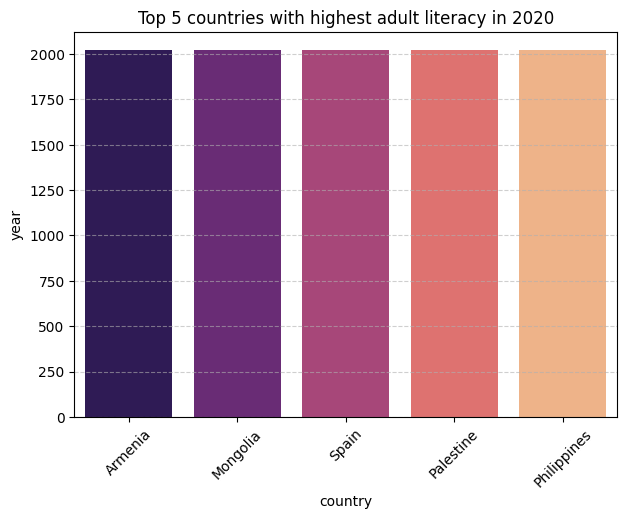


------------------------------------------------------------

TASK: Countries where female youth literacy < 80% 
QUERY RESULT (Data Table):
╒════════════╤═══════════════════════════════════╕
│ country    │   youth_literacy_female_age15to24 │
╞════════════╪═══════════════════════════════════╡
│ Others     │                           79.7994 │
├────────────┼───────────────────────────────────┤
│ Others     │                           79.5512 │
├────────────┼───────────────────────────────────┤
│ Others     │                           79.2422 │
├────────────┼───────────────────────────────────┤
│ Bangladesh │                           79      │
├────────────┼───────────────────────────────────┤
│ Cambodia   │                           79      │
├────────────┼───────────────────────────────────┤
│ East Timor │                           79      │
├────────────┼───────────────────────────────────┤
│ Egypt      │                           79      │
├────────────┼─────────────────────────────

/tmp/ipykernel_13805/2769785595.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


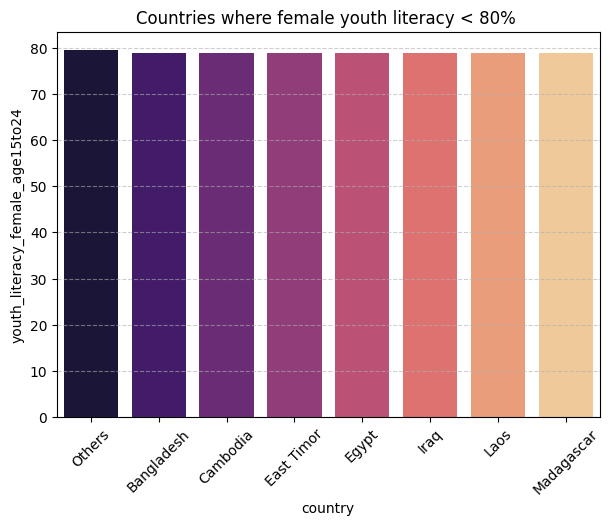


------------------------------------------------------------

TASK: Average adult literacy per continent
QUERY RESULT (Data Table):
╒═══════════════╤══════════════════════╕
│ continent     │   Avg_Adult_Literacy │
╞═══════════════╪══════════════════════╡
│ Africa        │              60.9139 │
├───────────────┼──────────────────────┤
│ Asia          │              87.1465 │
├───────────────┼──────────────────────┤
│ Europe        │              97.3966 │
├───────────────┼──────────────────────┤
│ North America │              87.9861 │
├───────────────┼──────────────────────┤
│ Oceania       │              93.4459 │
├───────────────┼──────────────────────┤
│ Others        │              82.3257 │
├───────────────┼──────────────────────┤
│ South America │              93.467  │
╘═══════════════╧══════════════════════╛


/tmp/ipykernel_13805/2769785595.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


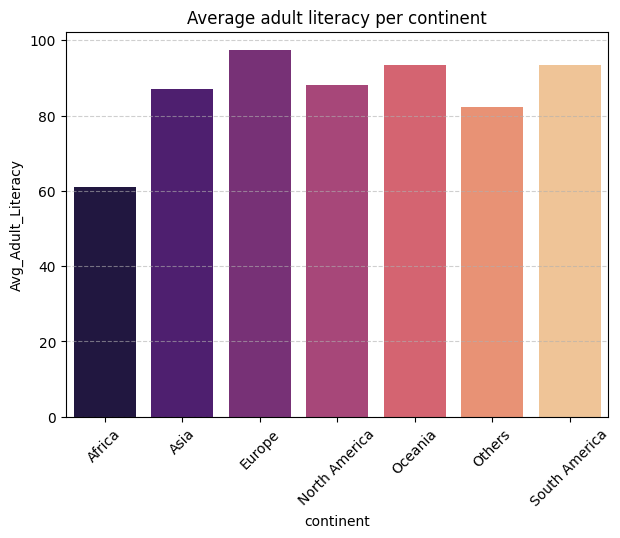


------------------------------------------------------------


In [49]:
# ===============================
#  LITERACY_RATES (3)
# ===============================
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

##Connect to your database
conn = sqlite3.connect('Global Literacy & Education Trends')

def process_query(title, query, plot_type='bar'):
    print(f"\n{'='*60}\nTASK: {title}\n{'='*60}")

    # Get the data
    df = pd.read_sql_query(query, conn)

    #Print the Query Answer (Data Table)
    print("QUERY RESULT (Data Table):")
    if df.empty:
        print("No results found for these criteria.")
    else:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

        # 2. Create the Visual
        plt.figure(figsize=(7, 5))
        if plot_type == 'bar':
            # Use the first column for X and the last for Y
            sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)
            plt.xticks(rotation=45)
        elif plot_type == 'line':
            sns.lineplot(data=df, x=df.columns[0], y=df.columns[-1], marker='o', color='crimson')

        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()
    print("\n" + "-"*60)

# --- RUNNING YOUR LITERACY RATES QUERIES ---

# QUERY 1: Top 5 countries with highest adult literacy in 2020
q1 = """
SELECT country, adult_literacy_both_sexes_age15to99, year
FROM literacy_rates
WHERE year = 2020
ORDER BY adult_literacy_both_sexes_age15to99 DESC
LIMIT 5;"""
process_query("Top 5 countries with highest adult literacy in 2020", q1,'bar')

# QUERY 2: Countries where female youth literacy < 80%
q2 = """
SELECT country, youth_literacy_female_age15to24
FROM literacy_rates
WHERE youth_literacy_female_age15to24 < 80
ORDER BY youth_literacy_female_age15to24 DESC LIMIT 10;
"""
process_query("Countries where female youth literacy < 80% ", q2,"bar")

# QUERY 3: Average adult literacy per continent
q3 = """
SELECT continent, AVG(adult_literacy_both_sexes_age15to99) AS Avg_Adult_Literacy
FROM literacy_rates
GROUP BY continent;
"""
process_query("Average adult literacy per continent", q3)

conn.close()


TASK: Countries with >20% Illiteracy (2000)
QUERY RESULT (Data Table):
╒══════════════════════════╤═══════════════════╕
│ country                  │   illiteracy_rate │
╞══════════════════════════╪═══════════════════╡
│ Chad                     │                74 │
├──────────────────────────┼───────────────────┤
│ Gambia                   │                63 │
├──────────────────────────┼───────────────────┤
│ Guinea-Bissau            │                59 │
├──────────────────────────┼───────────────────┤
│ Cote d'Ivoire            │                51 │
├──────────────────────────┼───────────────────┤
│ Central African Republic │                49 │
├──────────────────────────┼───────────────────┤
│ Mauritania               │                49 │
├──────────────────────────┼───────────────────┤
│ Togo                     │                47 │
├──────────────────────────┼───────────────────┤
│ Papua New Guinea         │                43 │
├──────────────────────────┼──────────────────

/tmp/ipykernel_13805/3883619011.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


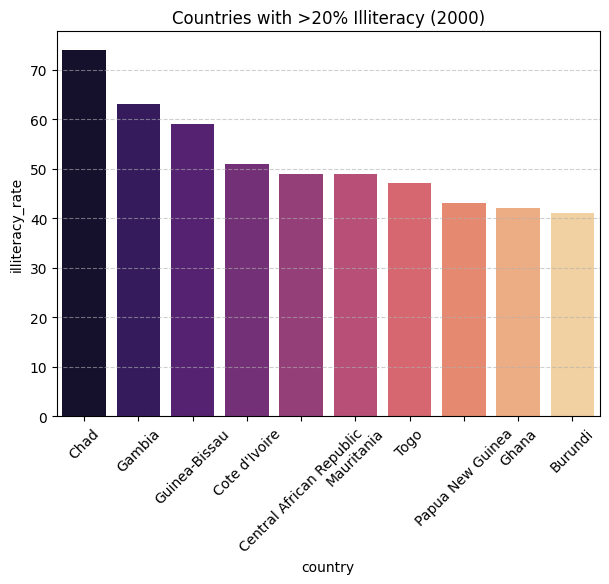


------------------------------------------------------------

TASK: Illiteracy Trend in India (2000-2020)
QUERY RESULT (Data Table):
╒════════╤═══════════════════╕
│   year │   illiteracy_rate │
╞════════╪═══════════════════╡
│   2001 │                39 │
├────────┼───────────────────┤
│   2006 │                37 │
├────────┼───────────────────┤
│   2011 │                31 │
╘════════╧═══════════════════╛


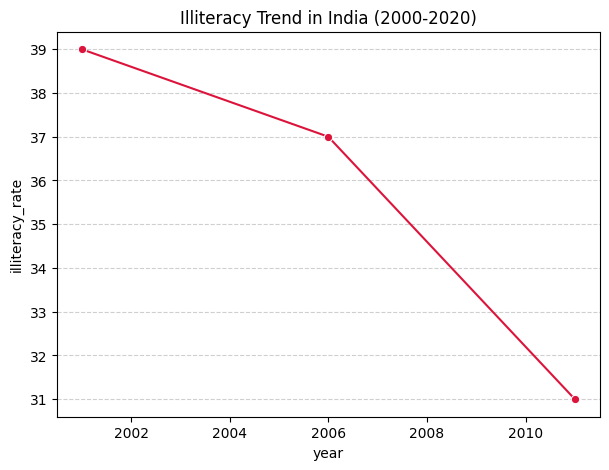


------------------------------------------------------------

TASK: Top 10 Highest Illiteracy Rates (Latest Year)
QUERY RESULT (Data Table):
╒═════════════╤═══════════════════╕
│ country     │   illiteracy_rate │
╞═════════════╪═══════════════════╡
│ Senegal     │          49.6442  │
├─────────────┼───────────────────┤
│ India       │          18       │
├─────────────┼───────────────────┤
│ Tunisia     │          13.7532  │
├─────────────┼───────────────────┤
│ World       │          12.644   │
├─────────────┼───────────────────┤
│ Vanuatu     │          12.0397  │
├─────────────┼───────────────────┤
│ El Salvador │          10       │
├─────────────┼───────────────────┤
│ Sri Lanka   │           7       │
├─────────────┼───────────────────┤
│ Jordan      │           5       │
├─────────────┼───────────────────┤
│ Others      │           4.38048 │
├─────────────┼───────────────────┤
│ Nauru       │           3.41346 │
╘═════════════╧═══════════════════╛


/tmp/ipykernel_13805/3883619011.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


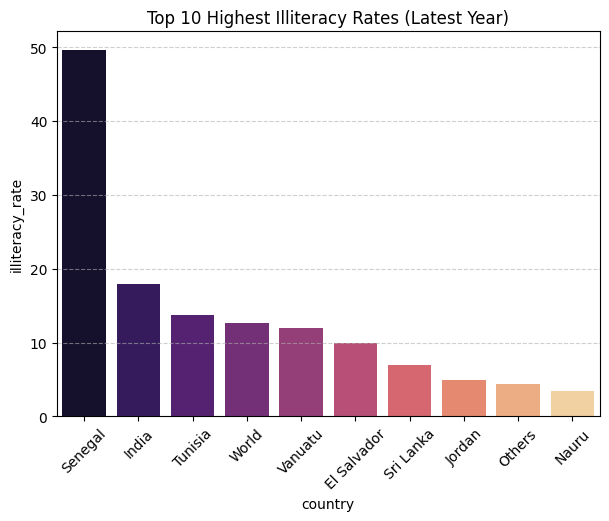


------------------------------------------------------------


In [50]:
# ===============================
#  ILLITERACY_POPULATION (3)
# ===============================
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

##Connect to your database
conn = sqlite3.connect('Global Literacy & Education Trends')

def process_query(title, query, plot_type='bar'):
    print(f"\n{'='*60}\nTASK: {title}\n{'='*60}")

    # Get the data
    df = pd.read_sql_query(query, conn)

    #Print the Query Answer (Data Table)
    print("QUERY RESULT (Data Table):")
    if df.empty:
        print("No results found for these criteria.")
    else:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

        # 2. Create the Visual
        plt.figure(figsize=(7, 5))
        if plot_type == 'bar':
            # Use the first column for X and the last for Y
            sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)
            plt.xticks(rotation=45)
        elif plot_type == 'line':
            sns.lineplot(data=df, x=df.columns[0], y=df.columns[-1], marker='o', color='crimson')

        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()
    print("\n" + "-"*60)


# --- RUNNING YOUR ILLITERACY POPULATION QUERIES ---

# Query 1: Countries with >20% illiteracy in 2000
q1 = """
SELECT country, illiteracy_rate
FROM illiteracy_population
WHERE year = 2000 AND illiteracy_rate > 20
ORDER BY illiteracy_rate DESC LIMIT 10;
"""
process_query("Countries with >20% Illiteracy (2000)", q1,"bar")

# Query 2: Trend for India
q2 = """
SELECT year, illiteracy_rate
FROM illiteracy_population
WHERE country = 'India' AND year BETWEEN 2000 AND 2020
ORDER BY year ASC;
"""
process_query("Illiteracy Trend in India (2000-2020)", q2,"line")

# Query 3: Top 10 Latest
q3 = """
SELECT country, illiteracy_rate
FROM illiteracy_population
WHERE year = (SELECT MAX(year) FROM illiteracy_population)
ORDER BY illiteracy_rate DESC LIMIT 10;
"""
process_query("Top 10 Highest Illiteracy Rates (Latest Year)", q3,"bar")

conn.close()



TASK: High Schooling but Low GDP (<$5000)
QUERY RESULT (Data Table):
╒════════════════════════╤═══════════════════════════════════════════════╤═════════╕
│ country                │   average_schooling_year_both_sexes_age15to64 │     gdp │
╞════════════════════════╪═══════════════════════════════════════════════╪═════════╡
│ Tajikistan             │                                      10.2454  │ 1365.23 │
├────────────────────────┼───────────────────────────────────────────────┼─────────┤
│ Bosnia and Herzegovina │                                      10.9883  │ 2183.54 │
├────────────────────────┼───────────────────────────────────────────────┼─────────┤
│ Lesotho                │                                       7.21    │ 2275.02 │
├────────────────────────┼───────────────────────────────────────────────┼─────────┤
│ Togo                   │                                       7.68    │ 2570.48 │
├────────────────────────┼───────────────────────────────────────────────┼──────

/tmp/ipykernel_13805/484275917.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


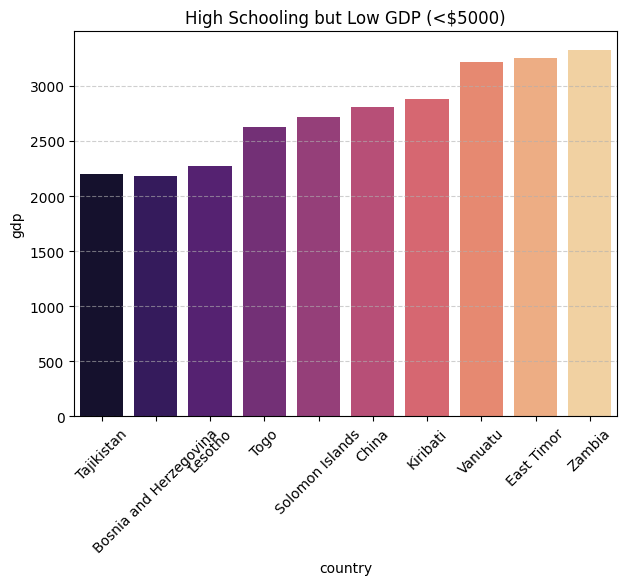


------------------------------------------------------------

TASK: Top 10: GDP Efficiency per Schooling Year (2020)
QUERY RESULT (Data Table):
╒══════════════════════╤═══════════════════════════════╕
│ country              │   Rank_gdp_per_schooling_year │
╞══════════════════════╪═══════════════════════════════╡
│ Qatar                │                      12096.5  │
├──────────────────────┼───────────────────────────────┤
│ Luxembourg           │                      11263.3  │
├──────────────────────┼───────────────────────────────┤
│ Singapore            │                       8873.89 │
├──────────────────────┼───────────────────────────────┤
│ Brunei               │                       8650.96 │
├──────────────────────┼───────────────────────────────┤
│ Kuwait               │                       7458.13 │
├──────────────────────┼───────────────────────────────┤
│ Ireland              │                       7421.29 │
├──────────────────────┼───────────────────────────────┤


/tmp/ipykernel_13805/484275917.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


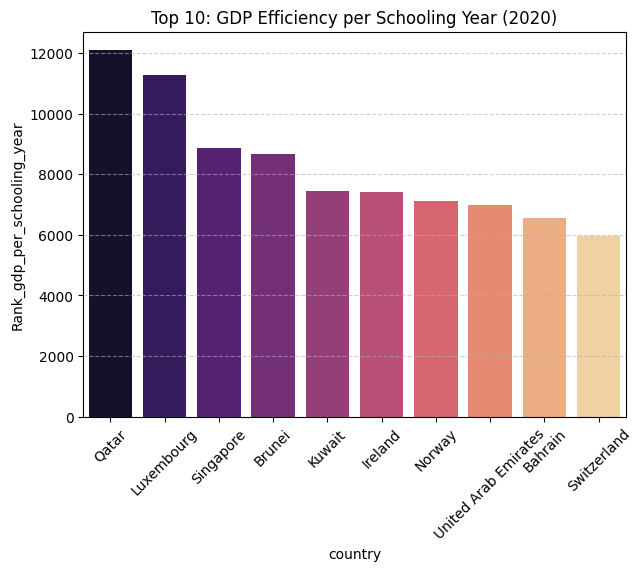


------------------------------------------------------------

TASK: Global Trend: Average Schooling Years (Over Time)
QUERY RESULT (Data Table):
╒════════╤════════════════════════╕
│   year │   global_avg_schooling │
╞════════╪════════════════════════╡
│   1990 │                6.60961 │
├────────┼────────────────────────┤
│   1991 │                7.01005 │
├────────┼────────────────────────┤
│   1992 │                6.57442 │
├────────┼────────────────────────┤
│   1993 │                6.69358 │
├────────┼────────────────────────┤
│   1994 │                6.08801 │
├────────┼────────────────────────┤
│   1995 │                7.19979 │
├────────┼────────────────────────┤
│   1996 │                7.22081 │
├────────┼────────────────────────┤
│   1997 │                5.7001  │
├────────┼────────────────────────┤
│   1998 │                3.22424 │
├────────┼────────────────────────┤
│   1999 │                9.54044 │
├────────┼────────────────────────┤
│   2000 │                

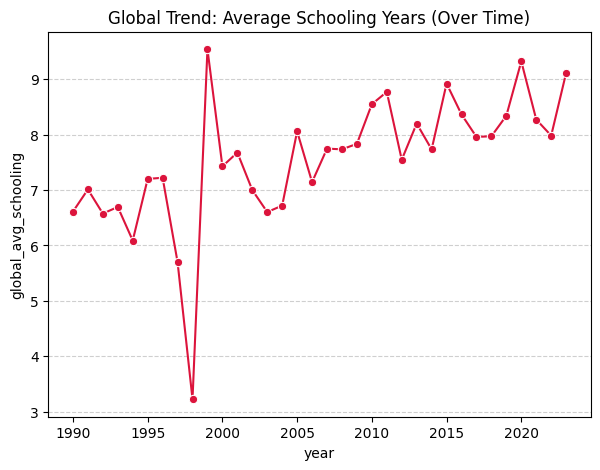


------------------------------------------------------------


In [51]:
# ===============================
#  GDP_SCHOOLING (3)
# ===============================

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

#Connect to your database
conn = sqlite3.connect('Global Literacy & Education Trends')

def process_query(title, query, plot_type='bar'):
    print(f"\n{'='*60}\nTASK: {title}\n{'='*60}")

    # Get the data
    df = pd.read_sql_query(query, conn)

    #Print the Query Answer (Data Table)
    print("QUERY RESULT (Data Table):")
    if df.empty:
        print("No results found for these criteria.")
    else:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

        # 2. Create the Visual
        plt.figure(figsize=(7, 5))
        if plot_type == 'bar':
            # Use the first column for X and the last for Y
            sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)
            plt.xticks(rotation=45)
        elif plot_type == 'line':
            sns.lineplot(data=df, x=df.columns[0], y=df.columns[-1], marker='o', color='crimson')

        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()
    print("\n" + "-"*60)

# --- RUNNING YOUR GDP & SCHOOLING QUERIES ---

# Query 1: High Schooling but Low GDP
q1 = """
SELECT country, average_schooling_year_both_sexes_age15to64, gdp
FROM gdp_schooling
WHERE average_schooling_year_both_sexes_age15to64 > 7
  AND gdp < 5000
ORDER BY gdp ASC;
"""
process_query("High Schooling but Low GDP (<$5000)", q1,"bar")

# Query 2: Rank Countries by GDP per Schooling (2020)
q2 = """
SELECT country, (gdp / average_schooling_year_both_sexes_age15to64) AS Rank_gdp_per_schooling_year
FROM gdp_schooling
WHERE year = 2020
ORDER BY Rank_gdp_per_schooling_year DESC
LIMIT 10;
"""
process_query("Top 10: GDP Efficiency per Schooling Year (2020)", q2,"bar")

# Query 3: Global Average Schooling Years Per Year
q3 = """
SELECT year, AVG(average_schooling_year_both_sexes_age15to64) AS global_avg_schooling
FROM gdp_schooling
GROUP BY year
ORDER BY year ASC;
"""
process_query("Global Trend: Average Schooling Years (Over Time)", q3, plot_type='line')

conn.close()


TASK: High GDP, Low Schooling (2020)
QUERY RESULT (Data Table):
╒══════════════════╤═════════╤═══════════════════════════════════════════════╕
│ country          │     gdp │   average_schooling_year_both_sexes_age15to64 │
╞══════════════════╪═════════╪═══════════════════════════════════════════════╡
│ Cambodia         │ 6128.78 │                                          5.81 │
├──────────────────┼─────────┼───────────────────────────────────────────────┤
│ Mauritania       │ 5963.24 │                                          5.55 │
├──────────────────┼─────────┼───────────────────────────────────────────────┤
│ Papua New Guinea │ 4077.63 │                                          4.84 │
├──────────────────┼─────────┼───────────────────────────────────────────────┤
│ Senegal          │ 4018.04 │                                          4.4  │
├──────────────────┼─────────┼───────────────────────────────────────────────┤
│ Sudan            │ 3401.25 │                                    

/tmp/ipykernel_13805/1560223307.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


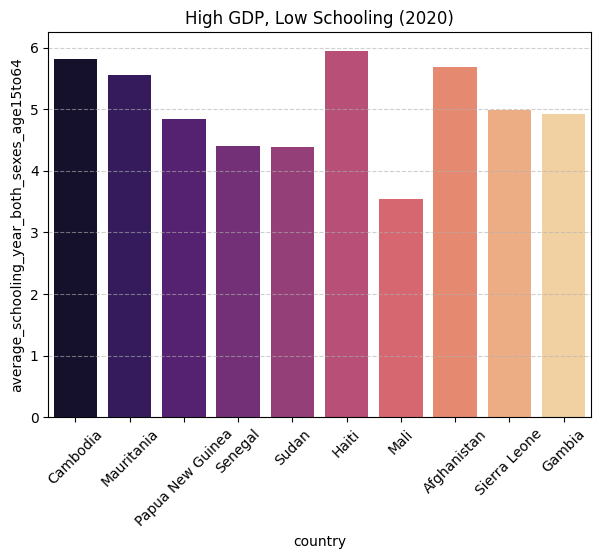


------------------------------------------------------------

TASK: Anomalies: High Schooling but High Illiteracy
QUERY RESULT (Data Table):
╒═══════════╤═══════════════════════════════════════════════╤═══════════════════╕
│ country   │   average_schooling_year_both_sexes_age15to64 │   illiteracy_rate │
╞═══════════╪═══════════════════════════════════════════════╪═══════════════════╡
│ Belize    │                                       9.29047 │           30      │
├───────────┼───────────────────────────────────────────────┼───────────────────┤
│ Bolivia   │                                       8.03634 │           20      │
├───────────┼───────────────────────────────────────────────┼───────────────────┤
│ Botswana  │                                       8.6277  │           31      │
├───────────┼───────────────────────────────────────────────┼───────────────────┤
│ Botswana  │                                       9.45499 │           19      │
├───────────┼─────────────────────────

/tmp/ipykernel_13805/1560223307.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


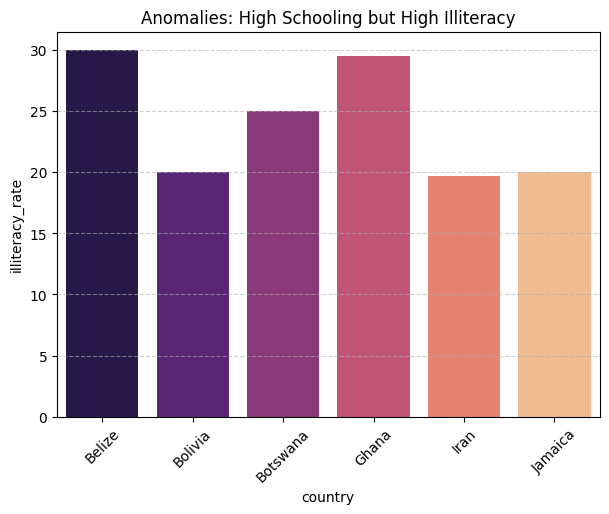


------------------------------------------------------------

TASK: India: Literacy vs. GDP Growth Trend
QUERY RESULT (Data Table):
╒════════╤═════════════════╤═════════╕
│   year │   literacy_rate │     gdp │
╞════════╪═════════════════╪═════════╡
│   2001 │              61 │ 3188.81 │
├────────┼─────────────────┼─────────┤
│   2006 │              63 │ 4129.78 │
├────────┼─────────────────┼─────────┤
│   2011 │              69 │ 5249.55 │
╘════════╧═════════════════╧═════════╛


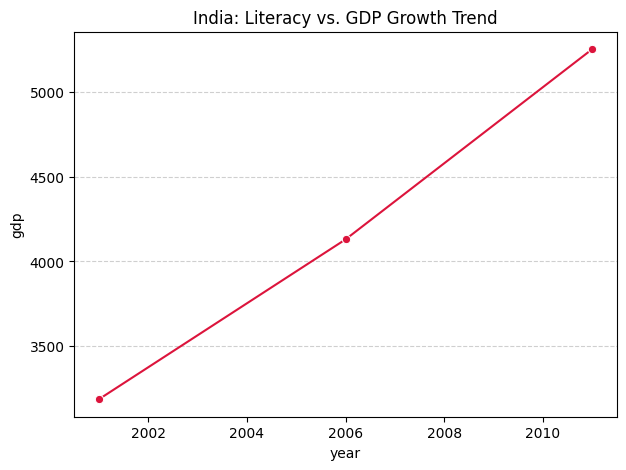


------------------------------------------------------------

TASK: Gender Gap in Wealthy Countries (2020)
QUERY RESULT (Data Table):
╒══════════════╤══════════════╤══════════╕
│ country      │   gender_gap │      gdp │
╞══════════════╪══════════════╪══════════╡
│ Saudi Arabia │            1 │  57420.7 │
├──────────────┼──────────────┼──────────┤
│ Oman         │            0 │  37560.6 │
├──────────────┼──────────────┼──────────┤
│ Singapore    │            0 │ 115893   │
├──────────────┼──────────────┼──────────┤
│ Kuwait       │           -1 │  49372.8 │
├──────────────┼──────────────┼──────────┤
│ Spain        │           -1 │  41553.4 │
╘══════════════╧══════════════╧══════════╛


/tmp/ipykernel_13805/1560223307.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)


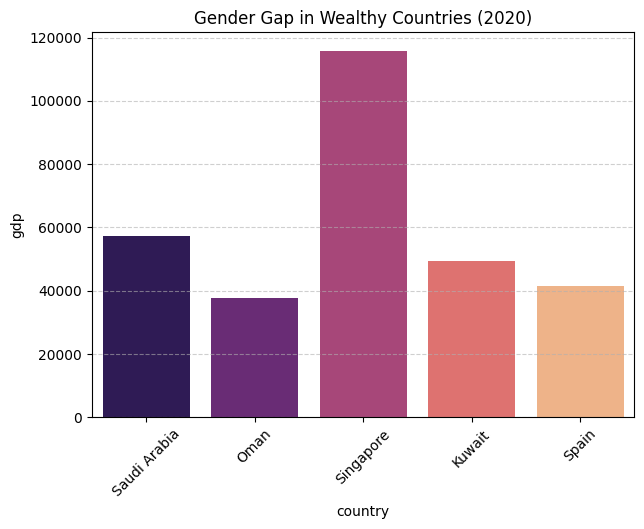


------------------------------------------------------------


In [52]:
# ===============================
#  JOIN QUERIES (4)
# ===============================

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

#Connect to your database
conn = sqlite3.connect('Global Literacy & Education Trends')

def process_query(title, query, x_col, y_col,plot_type='bar'):
    print(f"\n{'='*60}\nTASK: {title}\n{'='*60}")

    # Get the data
    df = pd.read_sql_query(query, conn)

    #Print the Query Answer (Data Table)
    print("QUERY RESULT (Data Table):")
    if df.empty:
        print("No results found for these criteria.")
    else:
        print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))

        # 2. Create the Visual
        plt.figure(figsize=(7, 5))
        if plot_type == 'bar':
            # Use the first column for X and the last for Y
            sns.barplot(data=df.head(15), x=df.columns[0], y=df.columns[-1], palette='magma',errorbar=None)
            plt.xticks(rotation=45)
        elif plot_type == 'line':
            sns.lineplot(data=df, x=df.columns[0], y=df.columns[-1], marker='o', color='crimson')

        plt.title(title)
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()
    print("\n" + "-"*60)

# --- RUNNING YOUR JOIN QUERIES ---

# Query 1: High GDP, Low Schooling (2020)
q1 = """
SELECT DISTINCT lr.country, gs.gdp, gs.average_schooling_year_both_sexes_age15to64
FROM literacy_rates lr
JOIN gdp_schooling gs ON lr.country = gs.country
WHERE gs.year = 2020 AND gs.average_schooling_year_both_sexes_age15to64 < 6
ORDER BY gs.gdp DESC
LIMIT 10;
"""
process_query("High GDP, Low Schooling (2020)", q1, 'country', 'gdp', 'bar')

# Query 2: High Illiteracy despite High Schooling
q2 = """
SELECT DISTINCT ir.country, gs.average_schooling_year_both_sexes_age15to64, ir.illiteracy_rate
FROM illiteracy_population ir
JOIN gdp_schooling gs ON ir.country = gs.country AND ir.year = gs.year
WHERE gs.average_schooling_year_both_sexes_age15to64 > (SELECT AVG(average_schooling_year_both_sexes_age15to64) FROM gdp_schooling)
  AND ir.illiteracy_rate > (SELECT AVG(illiteracy_rate) FROM illiteracy_population)
LIMIT 10;
"""
process_query("Anomalies: High Schooling but High Illiteracy", q2, 'average_schooling_year_both_sexes_age15to64', 'illiteracy_rate', 'bar')

# Query 3: Literacy vs. GDP Growth (Example: India)
q3 = """
SELECT ir.year, ir.literacy_rate, gs.gdp
FROM illiteracy_population ir
JOIN gdp_schooling gs ON ir.country = gs.country AND ir.year = gs.year
WHERE ir.country = 'India' AND ir.year BETWEEN 2000 AND 2020
ORDER BY ir.year ASC;
"""
process_query("India: Literacy vs. GDP Growth Trend", q3, 'year', 'gdp', 'line')

# Query 4: Youth Gender Gap in Wealthy Countries (2020)
q4 = """
SELECT DISTINCT lr.country,(lr.youth_literacy_male_age15to24 - lr.youth_literacy_female_age15to24) AS gender_gap, gs.gdp
FROM literacy_rates lr
JOIN gdp_schooling gs ON lr.country = gs.country AND lr.year = gs.year
WHERE lr.year = 2020 AND gs.gdp > 30000
ORDER BY gender_gap DESC
LIMIT 10;
"""
process_query("Gender Gap in Wealthy Countries (2020)", q4, 'country', 'gender_gap', 'bar')

conn.close()